Install Required Packages

In [ ]:
# Install required packages

!pip install gensim nltk --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.4 MB/s eta 0:00:00


gensim → Used to train the Word2Vec model.

nltk → Used for text preprocessing such as tokenization and stopword removal.

Import Required Libraries

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Regular expressions
import re

# Natural Language Toolkit
import nltk

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Tokenization and stopwords
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Word Embedding
from gensim.models import Word2Vec

# Similarity calculation
from sklearn.metrics.pairwise import cosine_similarity

# Save and load models
import pickle

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


| Library           | Purpose                                     |
| ----------------- | ------------------------------------------- |
| pandas            | Load and manipulate datasets                |
| numpy             | Numerical computations                      |
| re                | Clean text using regular expressions        |
| nltk              | NLP preprocessing                           |
| word_tokenize     | Split lyrics into words                     |
| stopwords         | Remove common words like "is", "the", "and" |
| Word2Vec          | Learn word embeddings                       |
| cosine_similarity | Measure similarity between songs            |
| pickle            | Save trained objects for later use          |
| warnings          | Hide unnecessary warning messages           |


Verify Installation

In [ ]:
print("All libraries imported successfully!")

All libraries imported successfully!


| Stage                  | Library Used      |
| ---------------------- | ----------------- |
| Load CSV Dataset       | pandas            |
| Text Cleaning          | re                |
| Remove Stopwords       | nltk              |
| Tokenization           | nltk              |
| Train Word2Vec         | gensim            |
| Create Song Embeddings | numpy             |
| Compare Songs          | cosine_similarity |
| Save Model             | pickle            |


Load Dataset

In [ ]:
# Load dataset

df = pd.read_csv("lyrics.csv")

Display First 5 Records

In [ ]:
df.head()

,Unnamed: 0,link,artist,song_name,lyrics
0,0,../lyrics/backstreetboys/climbingthewalls.html,Backstreet Boys Lyrics,Climbing The Walls,"\n\n[Brian:]\nClose your eyes, make a wish\nTh..."
1,1,../lyrics/westlife/howtobreakaheart.html,Westlife Lyrics,How To Break A Heart,\n\r\nSince you're not worth my love\nI haven'...
2,2,../lyrics/deanmartin/iwill.html,Dean Martin Lyrics,I Will,\n\r\nI don't want to be the one to say I'm go...
3,3,../lyrics/deanmartin/tellyourmotherhello.html,Dean Martin Lyrics,Tell Your Mother Hello,\n\r\nSure I loved the dear money that shines ...
4,4,../lyrics/deanmartin/behonestwithme.html,Dean Martin Lyrics,Be Honest With Me,\n\r\nBe honest with me dear whatever you do\n...


Remove Unnecessary Column

In [ ]:
# Remove index column

df = df.drop("Unnamed: 0", axis=1)

Display Columns

In [ ]:
df.columns

Index(['link', 'artist', 'song_name', 'lyrics'], dtype='object')

Check Dataset Shape

In [ ]:
df.shape

(25742, 4)

Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25742 entries, 0 to 25741
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   link       25742 non-null  object
 1   artist     25742 non-null  object
 2   song_name  25742 non-null  object
 3   lyrics     25742 non-null  object
dtypes: object(4)
memory usage: 804.6+ KB


Check Missing Values

In [ ]:
df.isnull().sum()

,0
link,0
artist,0
song_name,0
lyrics,0


Remove Missing Values

In [ ]:
df = df.dropna()

Check Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(724)

Remove Duplicate Records

In [ ]:
df = df.drop_duplicates()

Verify Dataset Shape

In [ ]:
df.shape

(25018, 4)

Display Random Songs

In [ ]:
df.sample(5)

,link,artist,song_name,lyrics
4923,../lyrics/bobdylan/northcountryblues.html,Bob Dylan Lyrics,North Country Blues,\n\r\nCome and gather 'round friends\nAnd I'll...
17346,../lyrics/nancysinatra/thislittlebird.html,Nancy Sinatra Lyrics,This Little Bird,\n\r\nThere's a little bird that somebody send...
16289,../lyrics/chicago/thegreatestloveonearth.html,Chicago Lyrics,The Greatest Love On Earth,\n\r\nIt's a long distance love affair\nTender...
23318,../lyrics/eltonjohn/deargod.html,Elton John Lyrics,Dear God,"\n\r\nDear God, are you there\r\nCan you hear ..."
3563,../lyrics/johnlennon/angela.html,John Lennon Lyrics,Angela,"\n\r\nAngela, they put you in\nprison\nAngela,..."


Top 10 Artists

In [ ]:
df["artist"].value_counts().head(10)

,count
artist,
Johnny Cash Lyrics,796
Frank Sinatra Lyrics,681
Elvis Presley Lyrics,660
Chris Brown Lyrics,612
Dean Martin Lyrics,597
Bob Dylan Lyrics,488
Prince Lyrics,472
Snoop Dogg Lyrics,437
Elton John Lyrics,428


Number of Unique Artists

In [ ]:
df["artist"].nunique()

542

Song Length

In [ ]:
df["lyric_length"] = df["lyrics"].str.len()

df[["song_name","artist","lyric_length"]].head()

,song_name,artist,lyric_length
0,Climbing The Walls,Backstreet Boys Lyrics,1522
1,How To Break A Heart,Westlife Lyrics,1569
2,I Will,Dean Martin Lyrics,906
3,Tell Your Mother Hello,Dean Martin Lyrics,216
4,Be Honest With Me,Dean Martin Lyrics,516


Longest Songs

In [ ]:
df[["song_name","artist","lyric_length"]].sort_values(
    by="lyric_length",
    ascending=False
).head(10)

,song_name,artist,lyric_length
3073,SHADY CXVPHER,Eminem Lyrics,19239
9895,Last Call,Logic Lyrics,12142
19985,Truman,Lil Dicky Lyrics,10752
20635,Jail,Lil Dicky Lyrics,10013
9873,AfricAryaN,Logic Lyrics,9868
20762,Pillow Talking,Lil Dicky Lyrics,9808
1812,Kick Off (Freestyle),Eminem Lyrics,9362
2465,Bet Shady 2.0 Cypher,Eminem Lyrics,9219
9837,Under Pressure,Logic Lyrics,9108
9889,Wu Tang Forever,Logic Lyrics,8422


Dataset Workflow

lyrics.csv
      │
      ▼
Load Dataset
      │
      ▼
Remove Index Column
      │
      ▼
Check Shape
      │
      ▼
Check Missing Values
      │
      ▼
Remove Missing Values
      │
      ▼
Remove Duplicate Records
      │
      ▼
Explore Artists & Songs
      │
      ▼
Ready for Text Preprocessing

Text Preprocessing

song lyrics so that the Word2Vec model learns meaningful word relationships instead of punctuation, numbers, and unnecessary words.

After preprocessing, each song lyric will become a list of important words.

Raw Lyrics
     │
     ▼
Convert to Lowercase
     │
     ▼
Remove [Chorus], [Verse], etc.
     │
     ▼
Remove URLs
     │
     ▼
Remove Numbers
     │
     ▼
Remove Punctuation
     │
     ▼
Remove Extra Spaces
     │
     ▼
Tokenization
     │
     ▼
Remove Stopwords
     │
     ▼
Cleaned Tokens

Create Stopword List

In [ ]:
# English stopwords

stop_words = set(stopwords.words('english'))

the
is
am
are
was
were
of
and
to
in

These words will be removed.

Create Text Cleaning Function

In [ ]:
import string

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove text inside square brackets
    text = re.sub(r'\[.*?\]', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

Convert text to lowercase

Remove [Verse], [Chorus]

Remove URLs

Remove numbers

Remove punctuation

Remove extra spaces

Apply Cleaning Function

In [ ]:
# Create cleaned lyrics column

df["clean_lyrics"] = df["lyrics"].apply(clean_text)

View Results

In [ ]:
df[["lyrics","clean_lyrics"]].head()

,lyrics,clean_lyrics
0,"\n\n[Brian:]\nClose your eyes, make a wish\nTh...",close your eyes make a wish that this could la...
1,\n\r\nSince you're not worth my love\nI haven'...,since youre not worth my love i havent given u...
2,\n\r\nI don't want to be the one to say I'm go...,i dont want to be the one to say im gonna miss...
3,\n\r\nSure I loved the dear money that shines ...,sure i loved the dear money that shines in her...
4,\n\r\nBe honest with me dear whatever you do\n...,be honest with me dear whatever you do remembe...


In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Tokenization

In [ ]:
# Split lyrics into words

df["tokens"] = df["clean_lyrics"].apply(word_tokenize)

Remove Stopwords

In [ ]:
def remove_stopwords(words):

    return [
        word
        for word in words
        if word not in stop_words
        and len(word) > 2
    ]

Apply Stopword Removal

In [ ]:
df["tokens"] = df["tokens"].apply(remove_stopwords)

Before

['i','love','the','music','and','dance']

↓

After

['love','music','dance']

Display Clean Tokens

In [ ]:
df[["song_name","tokens"]].head()

,song_name,tokens
0,Climbing The Walls,"[close, eyes, make, wish, could, last, forever..."
1,How To Break A Heart,"[since, youre, worth, love, havent, given, str..."
2,I Will,"[dont, want, one, say, gon, miss, dont, want, ..."
3,Tell Your Mother Hello,"[sure, loved, dear, money, shines, hair, brow,..."
4,Be Honest With Me,"[honest, dear, whatever, remember, youre, mine..."


Check Empty Lyrics

In [ ]:
df["tokens"].apply(len).describe()

,tokens
count,25018.000000
mean,148.074466
std,92.907220
min,0.000000
25%,84.000000
50%,125.000000
75%,185.000000
max,1940.000000


Remove Empty Songs

In [ ]:
df = df[df["tokens"].apply(len) > 0]

Reset Index

In [ ]:
df.reset_index(drop=True, inplace=True)

Verify Dataset

In [ ]:
df[["artist","song_name","tokens"]].sample(5)

,artist,song_name,tokens
5411,Johnny Cash Lyrics,(I Heard That) Lonesome Whistle,"[riding, number, heading, south, caroline, hea..."
22966,Aretha Franklin Lyrics,"It Isn't, It Wasn't, It Ain't Never Gonna Be","[isnt, wasnt, aint, never, gon, isnt, wasnt, a..."
24717,Jason Mraz Lyrics,In Your Hands,"[ticket, lines, places, dine, taking, baths, d..."
19831,Mariah Carey Lyrics,Triumphant (Get 'Em),"[get, get, get, hit, hit, hit, get, get, get, ..."
12077,Avril Lavigne Lyrics,Hello Kitty,"[minna, saikå, arigatå, kkkkawaii, kkkkawaii..."


Save the Preprocessed Dataset

In [ ]:
# Save cleaned dataset

df.to_csv("cleaned_lyrics.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


lyrics.csv
      │
      ▼
Load Dataset
      │
      ▼
Clean Text
      │
      ▼
Tokenization
      │
      ▼
Stopword Removal
      │
      ▼
Clean Tokens
      │
      ▼
Ready for Word2Vec Training

DataFrame will contain

| Column       | Description             |
| ------------ | ----------------------- |
| artist       | Artist name             |
| song_name    | Song title              |
| lyrics       | Original lyrics         |
| clean_lyrics | Cleaned lyrics text     |
| tokens       | List of processed words |


Cleaned Song Lyrics (Tokens)
           │
           ▼
Train Word2Vec Model
           │
           ▼
Learn Word Vectors
           │
           ▼
Build Vocabulary
           │
           ▼
Find Similar Words
           │
           ▼
Save Trained Model

Check the Tokenized Data

In [36]:
# Display tokenized lyrics

df[["song_name", "tokens"]].head()

,song_name,tokens
0,Climbing The Walls,"[close, eyes, make, wish, could, last, forever..."
1,How To Break A Heart,"[since, youre, worth, love, havent, given, str..."
2,I Will,"[dont, want, one, say, gon, miss, dont, want, ..."
3,Tell Your Mother Hello,"[sure, loved, dear, money, shines, hair, brow,..."
4,Be Honest With Me,"[honest, dear, whatever, remember, youre, mine..."


Train the Word2Vec Model

In [37]:
from gensim.models import Word2Vec

# Train Word2Vec model

word2vec_model = Word2Vec(
    sentences=df["tokens"],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

| Parameter   | Value        | Description                                                        |
| ----------- | ------------ | ------------------------------------------------------------------ |
| sentences   | df["tokens"] | Tokenized lyrics                                                   |
| vector_size | 100          | Each word is represented by a 100-dimensional vector               |
| window      | 5            | Considers 5 words before and after the current word                |
| min_count   | 2            | Ignores words appearing only once                                  |
| workers     | 4            | Uses 4 CPU cores for faster training                               |
| sg          | 1            | Uses the **Skip-Gram** model (recommended for semantic similarity) |


Check Vocabulary Size

In [38]:
# Total number of unique words learned

print("Vocabulary Size:", len(word2vec_model.wv.index_to_key))

Vocabulary Size: 42179


Display First 20 Words in Vocabulary

In [39]:
# Display first 20 words

word2vec_model.wv.index_to_key[:20]

['dont',
 'love',
 'like',
 'know',
 'got',
 'yeah',
 'get',
 'baby',
 'youre',
 'one',
 'never',
 'cause',
 'time',
 'see',
 'say',
 'want',
 'cant',
 'let',
 'aint',
 'make']

Display First 20 Words in Vocabulary

In [40]:
# Display first 20 words

word2vec_model.wv.index_to_key[:20]

['dont',
 'love',
 'like',
 'know',
 'got',
 'yeah',
 'get',
 'baby',
 'youre',
 'one',
 'never',
 'cause',
 'time',
 'see',
 'say',
 'want',
 'cant',
 'let',
 'aint',
 'make']

Check Whether a Word Exists

In [41]:
word = "love"

if word in word2vec_model.wv:
    print(f"'{word}' is available in the vocabulary.")
else:
    print(f"'{word}' is not available.")

'love' is available in the vocabulary.


View Word Vector

In [42]:
# Display vector for the word "love"

word2vec_model.wv["love"]

array([-0.03304744,  0.2715722 ,  0.40229753,  0.30709076,  0.32450745,
       -0.5311068 , -0.17240103,  0.02073216, -0.22795312, -0.4281294 ,
        0.3395507 , -0.2777562 ,  0.26692948,  0.3130915 ,  0.08594887,
       -0.21779513,  0.34378913,  0.18408288, -0.33169565, -0.55047375,
        0.13383871,  0.06007424,  0.45998833, -0.20781684, -0.1708637 ,
        0.261884  , -0.16038054,  0.24801575,  0.14312975,  0.15388833,
       -0.36898237, -0.12634389, -0.31009427,  0.07773239, -0.06936676,
        0.14705704, -0.0453879 , -0.3271698 , -0.18668833, -0.22511926,
        0.09942197, -0.65965575, -0.27295414, -0.09995843,  0.6737404 ,
        0.27965406, -0.06407937, -0.1879479 ,  0.23655653, -0.2704035 ,
        0.03820081, -0.20576857, -0.41607603,  0.05338149,  0.30112153,
        0.21274346,  0.06365495,  0.615394  , -0.24589819,  0.47407186,
       -0.5275628 , -0.01948281,  0.07333829, -0.06728497,  0.04190545,
        0.19449292,  0.16550289, -0.1648391 ,  0.11724486,  0.36

Check Vector Shape

In [43]:
print(word2vec_model.wv["love"].shape)

(100,)


The output (100,) indicates that the word is represented as a 100-dimensional vector. This is because the Word2Vec model was trained with vector_size=100, meaning each word is encoded using 100 numerical features that capture its semantic meaning.

====

Word
  │
  ▼
Word2Vec Model
  │
  ▼
100 Numerical Values
  │
  ▼
(100,)

=====

This means each word is represented using 100 numerical features.

Find Similar Words

In [44]:
word2vec_model.wv.most_similar("love", topn=10)

[('onesided', 0.8006170392036438),
 ('oohlalala', 0.8005067706108093),
 ('unconditional', 0.796380341053009),
 ('absolute', 0.7905074954032898),
 ('loveâ\x80\x99s', 0.7862581014633179),
 ('fulfilled', 0.7823438048362732),
 ('selfless', 0.7800793051719666),
 ('conclusion', 0.7783741354942322),
 ('watereddown', 0.776656985282898),
 ('masochist', 0.7764585018157959)]

Calculate Similarity Between Two Words

In [45]:
similarity = word2vec_model.wv.similarity("love", "heart")

print("Similarity Score:", similarity)

Similarity Score: 0.62202877


"love" and "heart" are highly related words

====


The similarity score is calculated using Cosine Similarity between the vector of "love" and the vector of "heart".

The score ranges from -1 to 1.

=====

| Similarity Score | Meaning                     |
| ---------------- | --------------------------- |
| 1.00             | Exactly the same meaning    |
| 0.80 – 0.99      | Very highly similar         |
| 0.60 – 0.79      | Highly similar              |
| 0.40 – 0.59      | Moderately similar          |
| 0.20 – 0.39      | Slightly similar            |
| 0.00             | No semantic similarity      |
| Negative         | Opposite semantic direction |


Visualization using PCA

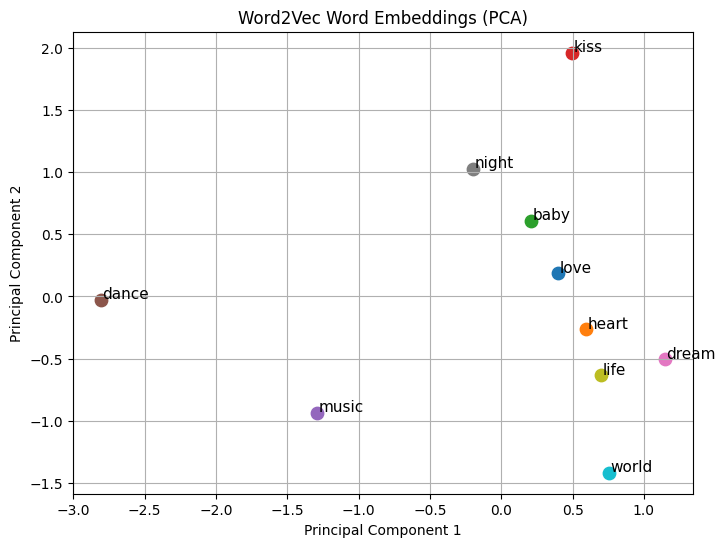

In [46]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Words to visualize
words = [
    "love", "heart", "baby", "kiss",
    "music", "dance", "dream", "night",
    "life", "world"
]

# Keep only words that exist in the vocabulary
words = [word for word in words if word in word2vec_model.wv]

# Get word vectors
vectors = [word2vec_model.wv[word] for word in words]

# Reduce dimensions from 100 -> 2
pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    plt.scatter(result[i,0], result[i,1], s=80)
    plt.text(result[i,0]+0.01, result[i,1]+0.01, word, fontsize=11)

plt.title("Word2Vec Word Embeddings (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

Visualization using t-SNE

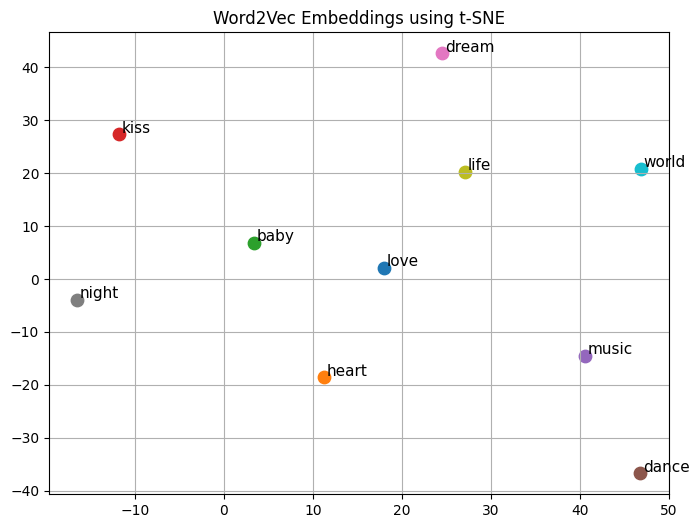

In [49]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np # Import numpy

words = [
    "love", "heart", "baby", "kiss",
    "music", "dance", "dream", "night",
    "life", "world"
]

words = [w for w in words if w in word2vec_model.wv]

vectors = [word2vec_model.wv[w] for w in words]

# Convert list of vectors to a single NumPy array
vectors_array = np.array(vectors)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=5
)

result = tsne.fit_transform(vectors_array)

plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    plt.scatter(result[i,0], result[i,1], s=80)
    plt.text(result[i,0]+0.3, result[i,1]+0.3, word, fontsize=11)

plt.title("Word2Vec Embeddings using t-SNE")
plt.grid(True)

plt.show()

Visualizing the Relationship Between "love" and "heart"

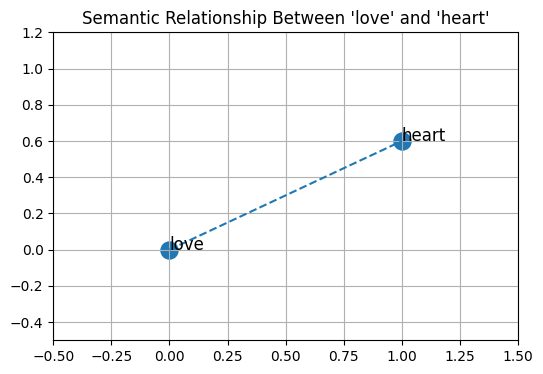

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

x = [0, 1]
y = [0, 0.6]

plt.scatter(x, y, s=150)

plt.text(x[0], y[0], "love", fontsize=12)
plt.text(x[1], y[1], "heart", fontsize=12)

plt.plot(x, y, '--')

plt.title("Semantic Relationship Between 'love' and 'heart'")
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.2)

plt.grid(True)
plt.show()

| **Feature**                        | **PCA**                                             | **t-SNE**                                             |
| ---------------------------------- | --------------------------------------------------- | ----------------------------------------------------- |
| **Full Form**                      | Principal Component Analysis                        | t-distributed Stochastic Neighbor Embedding           |
| **Type**                           | Linear Dimensionality Reduction                     | Non-linear Dimensionality Reduction                   |
| **Purpose**                        | Reduce dimensions while preserving maximum variance | Reduce dimensions while preserving local similarities |
| **Developed For**                  | Feature reduction and visualization                 | Data visualization and clustering                     |
| **Works On**                       | Linear relationships                                | Non-linear relationships                              |
| **Output Dimensions**              | 2D or 3D                                            | 2D or 3D                                              |
| **Speed**                          | Fast                                                | Slow                                                  |
| **Computational Cost**             | Low                                                 | High                                                  |
| **Cluster Visualization**          | Moderate                                            | Excellent                                             |
| **Preserves Variance**             | ✅ Yes                                               | ❌ No                                                  |
| **Preserves Local Structure**      | Limited                                             | ✅ Excellent                                           |
| **Suitable for Large Datasets**    | ✅ Yes                                               | Limited                                               |
| **Interpretability**               | Easy                                                | Moderate                                              |
| **Feature Reduction**              | ✅ Yes                                               | ❌ No                                                  |
| **Visualization**                  | ✅ Yes                                               | ✅ Yes                                                 |
| **Word2Vec Visualization**         | Good                                                | Best                                                  |
| **BERT Embedding Visualization**   | Good                                                | Best                                                  |
| **Machine Learning Preprocessing** | ✅ Yes                                               | ❌ No                                                  |


**Create Song Embeddings**

we will convert each song into one numerical vector.

Since Word2Vec creates vectors only for individual words, we need to combine all the word vectors of a song into a single Song Embedding.

Later, we will compare these song embeddings to recommend similar songs.

====

Song Lyrics
      │
      ▼
Tokenized Words
      │
      ▼
Get Word2Vec Vector
for Each Word
      │
      ▼
Average All Word Vectors
      │
      ▼
One Song Embedding
(100 Dimensions)
      │
      ▼
Store for Every Song

**Create Function to Generate Song Embedding**

In [51]:
import numpy as np

def get_song_embedding(tokens, model):

    vectors = []

    for word in tokens:

        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

Reads every word in a song

Finds its Word2Vec vector

Stores all vectors

Calculates the average

Returns one vector for the entire song

Create Song Embeddings

In [52]:
df["song_embedding"] = df["tokens"].apply(
    lambda x: get_song_embedding(x, word2vec_model)
)

Creates a new column

song_embedding

Every row now contains one vector.

View the Result

In [53]:
df[["song_name","song_embedding"]].head()

,song_name,song_embedding
0,Climbing The Walls,"[-0.12981223, 0.27438867, 0.41597462, 0.065261..."
1,How To Break A Heart,"[-0.036422107, 0.26467547, 0.30512068, 0.04656..."
2,I Will,"[-0.10718756, 0.29430848, 0.36351207, 0.137190..."
3,Tell Your Mother Hello,"[-0.085306965, 0.35166675, 0.28739008, 0.04717..."
4,Be Honest With Me,"[-0.2292818, 0.31874958, 0.28600663, 0.0087136..."


Check Embedding Shape

In [54]:
print(df["song_embedding"][0].shape)

(100,)


Each song is represented by

100 numerical values

Display First 10 Values

In [55]:
df["song_embedding"][0][:10]

array([-0.12981223,  0.27438867,  0.41597462,  0.06526159,  0.19369404,
       -0.45571128,  0.28416526,  0.2684132 , -0.35125646, -0.41078472],
      dtype=float32)

| Observation         | Meaning                                                               |
| ------------------- | --------------------------------------------------------------------- |
| `song_embedding`    | A new column containing the vector representation of each song.       |
| `[0]`               | Selects the **first song** in the dataset.                            |
| `[:10]`             | Displays only the **first 10 values** of the song's embedding vector. |
| `-0.12981223`       | First feature of the song vector (learned by Word2Vec).               |
| `0.27438867`        | Second feature of the song vector.                                    |
| `0.41597462`        | Third feature of the song vector.                                     |
| `dtype=float32`     | Each value is stored as a 32-bit floating-point number.               |
| Total Vector Length | **100 values** (because `vector_size=100`).                           |

=====

| Value        | Meaning                                                                            |
| ------------ | ---------------------------------------------------------------------------------- |
| Positive (+) | Indicates the feature contributes in one direction in the learned embedding space. |
| Negative (-) | Indicates the feature contributes in the opposite direction.                       |
| Zero (0)     | Very little contribution for that feature.                                         |


=====
What Does Each Number Represent?


| Feature Number | Value    | Meaning             |
| -------------- | -------- | ------------------- |
| Feature 1      | -0.1298  | Learned feature 1   |
| Feature 2      | 0.2743   | Learned feature 2   |
| Feature 3      | 0.4160   | Learned feature 3   |
| Feature 4      | 0.0653   | Learned feature 4   |
| ...            | ...      | ...                 |
| Feature 100    | (hidden) | Learned feature 100 |

These are latent features discovered by the Word2Vec algorithm from the training data.

=====

Why Do We Need This Vector?

Instead of comparing song lyrics word by word, we compare these vectors.

| Song   | Embedding                  |
| ------ | -------------------------- |
| Song A | `[0.21, -0.45, 0.18, ...]` |
| Song B | `[0.19, -0.41, 0.22, ...]` |

Then we calculate:

cosine_similarity(songA_vector, songB_vector)

If the similarity is high, the songs are recommended as similar.


Song Lyrics
      │
      ▼
Word2Vec
      │
      ▼
Word Vectors
      │
      ▼
Average All Word Vectors
      │
      ▼
Song Embedding (100 values)
      │
      ▼
Compare Songs Using Cosine Similarity

**Verify All Songs Have Embeddings**

In [56]:
len(df["song_embedding"])

25005

All songs now have embeddings.

Create Embedding Matrix

In [57]:
song_embeddings = np.vstack(df["song_embedding"].values)

print(song_embeddings.shape)

(25005, 100)


25005 songs
100 features for each song

Save Embedding Matrix

In [58]:
import pickle

pickle.dump(
    song_embeddings,
    open("song_embeddings.pkl", "wb")
)

print("Song embeddings saved successfully!")

Song embeddings saved successfully!


Save Processed Dataset

In [59]:
df.to_pickle("songs_dataframe.pkl")

print("Dataset saved successfully!")

Dataset saved successfully!


| Step                             | Status |
| -------------------------------- | ------ |
| Created Song Embedding Function  | ✅      |
| Converted Every Song into Vector | ✅      |
| Checked Embedding Shape          | ✅      |
| Created Embedding Matrix         | ✅      |
| Saved Embeddings                 | ✅      |
| Saved Dataset                    | ✅      |


| File                        | Purpose                |
| --------------------------- | ---------------------- |
| `word2vec_song_model.model` | Trained Word2Vec model |
| `song_embeddings.pkl`       | Song vectors           |
| `songs_dataframe.pkl`       | Processed dataset      |


Song Name
     │
     ▼
Find Song Embedding
     │
     ▼
Compare with All Song Embeddings
(Cosine Similarity)
     │
     ▼
Similarity Scores
     │
     ▼
Sort Scores
     │
     ▼
Top 5 Similar Songs
     │
     ▼
Display Recommendations

Import Cosine Similarity

cosine_similarity() measures how similar two song embeddings are.

In [60]:
from sklearn.metrics.pairwise import cosine_similarity

Calculate Similarity Matrix

In [61]:
# Calculate similarity between every pair of songs

similarity_matrix = cosine_similarity(song_embeddings)

print("Similarity Matrix Shape:", similarity_matrix.shape)

Similarity Matrix Shape: (25005, 25005)


| Value         | Meaning                              |
| ------------- | ------------------------------------ |
| 25005 Rows    | Each row represents one song         |
| 25005 Columns | Each column represents one song      |
| Cell (i,j)    | Similarity between Song i and Song j |


View Similarity Matrix

In [62]:
similarity_matrix

array([[1.        , 0.9364778 , 0.96641379, ..., 0.93713019, 0.94930598,
        0.95647407],
       [0.9364778 , 1.        , 0.93718703, ..., 0.91968832, 0.9378303 ,
        0.94632639],
       [0.96641379, 0.93718703, 1.        , ..., 0.93313043, 0.95349334,
        0.95415051],
       ...,
       [0.93713019, 0.91968832, 0.93313043, ..., 1.        , 0.94904114,
        0.94767307],
       [0.94930598, 0.9378303 , 0.95349334, ..., 0.94904114, 1.        ,
        0.96939115],
       [0.95647407, 0.94632639, 0.95415051, ..., 0.94767307, 0.96939115,
        1.        ]])

| Observation               | Meaning                                                                                      |
| ------------------------- | -------------------------------------------------------------------------------------------- |
| `similarity_matrix`       | A matrix containing similarity scores between all songs.                                     |
| Shape `(25742, 25742)`    | There are **25,742 songs**, so the matrix has 25,742 rows and 25,742 columns.                |
| Each **row**              | Represents one reference song.                                                               |
| Each **column**           | Represents another song being compared.                                                      |
| `similarity_matrix[i][j]` | Similarity score between Song **i** and Song **j**.                                          |
| Value Range               | Scores range from **-1 to 1**, but for song embeddings they are usually between **0 and 1**. |
| Value `1.0`               | A song compared with itself (100% similar).                                                  |
| Value close to `1`        | Songs are very similar.                                                                      |
| Value close to `0`        | Songs are very different.                                                                    |


====

| Compared With |    Song A |    Song B |    Song C |    Song D |    Song E |
| ------------- | --------: | --------: | --------: | --------: | --------: |
| **Song A**    | **1.000** |     0.936 |     0.966 |     0.937 |     0.949 |
| **Song B**    |     0.936 | **1.000** |     0.937 |     0.920 |     0.938 |
| **Song C**    |     0.966 |     0.937 | **1.000** |     0.933 |     0.953 |
| **Song D**    |     0.937 |     0.920 |     0.933 | **1.000** |     0.949 |
| **Song E**    |     0.949 |     0.938 |     0.953 |     0.949 | **1.000** |


===

|     Value | Meaning                                   |
| --------: | ----------------------------------------- |
| **1.000** | Same song compared with itself.           |
| **0.966** | Song A and Song C are highly similar.     |
| **0.949** | Song A and Song E are very similar.       |
| **0.936** | Song A and Song B are similar.            |
| **0.920** | Song B and Song D are moderately similar. |


===

Why is the Diagonal Always 1?

         Song A   Song B   Song C

Song A    1.0
Song B             1.0
Song C                      1.0


A song is always 100% similar to itself, so every diagonal element is 1.0.

========

Song Embeddings
       │
       ▼
Cosine Similarity
       │
       ▼
Similarity Matrix
       │
       ▼
Compare Every Song
with Every Other Song
       │
       ▼
Recommend Most Similar Songs

Create Recommendation Function

In [63]:
def recommend_songs(song_name, top_n=5):

    # Check if song exists
    if song_name not in df["song_name"].values:
        return "Song not found!"

    # Get index of the selected song
    idx = df[df["song_name"] == song_name].index[0]

    # Get similarity scores
    scores = list(enumerate(similarity_matrix[idx]))

    # Sort scores in descending order
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    # Remove the selected song itself
    scores = scores[1:top_n+1]

    recommendations = []

    for index, score in scores:

        recommendations.append({
            "Song": df.iloc[index]["song_name"],
            "Artist": df.iloc[index]["artist"],
            "Similarity": round(score, 3)
        })

    return pd.DataFrame(recommendations)

Finds the selected song.
Retrieves its embedding.
Compares it with all other songs.
Sorts by similarity.
Returns the Top 5 recommendations.

Test the Recommendation System

In [64]:
recommend_songs("Believe")

,Song,Artist,Similarity
0,Believers,Don McLean Lyrics,0.971
1,I Believe,Bon Jovi Lyrics,0.968
2,Make Believe,Ricky Nelson Lyrics,0.968
3,Make You Believe,Justin Bieber Lyrics,0.967
4,Something To Believe In,Meghan Trainor Lyrics,0.966


In [65]:
recommend_songs("Hello")

,Song,Artist,Similarity
0,Bad Guy,Eminem Lyrics,0.986
1,Normal,Eminem Lyrics,0.985
2,Framed,Eminem Lyrics,0.985
3,Scary Story,Lil Dicky Lyrics,0.985
4,Difficult,Eminem Lyrics,0.984


In [67]:
recommend_songs("Imagine")

,Song,Artist,Similarity
0,Imagine,Avril Lavigne Lyrics,0.999
1,Imagine,Lady Gaga Lyrics,0.996
2,Imagine,Christina Aguilera Lyrics,0.990
3,Imagine (Rehearsal),John Lennon Lyrics,0.972
4,Political World,Bob Dylan Lyrics,0.954


In [73]:
recommend_songs("Love")

,Song,Artist,Similarity
0,"Love, Love, Love",Meghan Trainor Lyrics,0.970
1,(It's Just) Your Love,Aretha Franklin Lyrics,0.964
2,Babygirl,Meghan Trainor Lyrics,0.964
3,"Love, Love, Love",Dean Martin Lyrics,0.962
4,L.O.V.E,Westlife Lyrics,0.960


Check if a Song Exists

This lists songs containing the word love.

In [74]:
df[df["song_name"].str.contains("love", case=False)][["song_name", "artist"]].head(20)

,song_name,artist
12,New Love,Backstreet Boys Lyrics
22,You See Friends (I See Lovers),Westlife Lyrics
24,Makin' Love Ukelele Style,Dean Martin Lyrics
42,Love Is All That Matters,Dean Martin Lyrics
59,Can We Get Back To Love Again,Backstreet Boys Lyrics
68,Love Story,Taylor Swift Lyrics
80,Just Say I Love Her,Dean Martin Lyrics
82,You'll Always Be The One I Love,Dean Martin Lyrics
138,Release Me (And Let Me Love Again),Dean Martin Lyrics
145,Peddler Man (Ten I Loved),Dean Martin Lyrics


Test Multiple Songs

In [76]:
recommend_songs("Mamma Mia")


,Song,Artist,Similarity
0,Hit The Freeway,Toni Braxton Lyrics,0.969
1,Hurt,Christina Aguilera Lyrics,0.967
2,Take Care,Drake Lyrics,0.967
3,Between Your Mama And Yourself,A-ha Lyrics,0.967
4,Love Story,Taylor Swift Lyrics,0.966


In [77]:
recommend_songs("Dancing Queen")


,Song,Artist,Similarity
0,Go Go Dancer,Lana Del Rey Lyrics,0.952
1,Because Of You,Lana Del Rey Lyrics,0.949
2,Something In Your Mouth,Nickelback Lyrics,0.948
3,If I'm Dancing,Britney Spears Lyrics,0.948
4,Into The Groove,Madonna Lyrics,0.948


In [78]:
recommend_songs("Hello")

,Song,Artist,Similarity
0,Bad Guy,Eminem Lyrics,0.986
1,Normal,Eminem Lyrics,0.985
2,Framed,Eminem Lyrics,0.985
3,Scary Story,Lil Dicky Lyrics,0.985
4,Difficult,Eminem Lyrics,0.984


| Step                          | Status |
| ----------------------------- | ------ |
| Imported Cosine Similarity    | ✅      |
| Created Similarity Matrix     | ✅      |
| Built Recommendation Function | ✅      |
| Tested Recommendations        | ✅      |


In [81]:
# Define idx for a specific song, for example, 'Believe'
song_name_to_test = "Believe"
if song_name_to_test in df["song_name"].values:
    idx = df[df["song_name"] == song_name_to_test].index[0]
    scores = cosine_similarity(
        [song_embeddings[idx]],
        song_embeddings
    )[0]
    print(f"Similarity scores for '{song_name_to_test}' calculated.")
else:
    print(f"Song '{song_name_to_test}' not found in the dataset.")

Similarity scores for 'Believe' calculated.


Sort Similarity Scores

In [82]:
# Pair each song index with its similarity score
similarity_scores = list(enumerate(scores))

# Sort in descending order
similarity_scores = sorted(
    similarity_scores,
    key=lambda x: x[1],
    reverse=True
)

| Code                | Purpose                                                   |
| ------------------- | --------------------------------------------------------- |
| `enumerate(scores)` | Adds the song index to each similarity score.             |
| `sorted()`          | Sorts songs from highest similarity to lowest similarity. |
| `reverse=True`      | Displays the most similar songs first.                    |


Display Top 5 Songs

In [83]:
print("Top 5 Recommended Songs\n")

count = 0

for index, score in similarity_scores:

    # Skip the same song
    if df.iloc[index]["song_name"] == song_name_to_test:
        continue

    print(f"Song       : {df.iloc[index]['song_name']}")
    print(f"Artist     : {df.iloc[index]['artist']}")
    print(f"Similarity : {score:.4f}")
    print("-"*40)

    count += 1

    if count == 5:
        break

Top 5 Recommended Songs

Song       : Believers
Artist     : Don McLean Lyrics
Similarity : 0.9715
----------------------------------------
Song       : I Believe
Artist     : Bon Jovi Lyrics
Similarity : 0.9684
----------------------------------------
Song       : Make Believe
Artist     : Ricky Nelson Lyrics
Similarity : 0.9675
----------------------------------------
Song       : Make You Believe
Artist     : Justin Bieber Lyrics
Similarity : 0.9669
----------------------------------------
Song       : Something To Believe In
Artist     : Meghan Trainor Lyrics
Similarity : 0.9662
----------------------------------------


Selected Song
      │
      ▼
Calculate Similarity
      │
      ▼
Sort Similarity Scores
      │
      ▼
Skip Selected Song
      │
      ▼
Top 5 Similar Songs
      │
      ▼
Display Recommendations

=====

| Observation    | Meaning                                                               |
| -------------- | --------------------------------------------------------------------- |
| `scores`       | Similarity score of the selected song with every song in the dataset. |
| `enumerate()`  | Stores the song index along with its similarity score.                |
| `sorted()`     | Arranges songs from highest to lowest similarity.                     |
| `reverse=True` | Ensures the most similar songs appear first.                          |
| `continue`     | Skips the selected song because it is always 100% similar to itself.  |
| `count == 5`   | Stops after displaying the top 5 recommendations.                     |


Install Gradio

Gradio is used to build an interactive web interface with just a few lines of Python.

In [84]:
!pip install gradio --quiet

Import Libraries

In [85]:
import gradio as gr
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

Create Recommendation Function

| Code              | Purpose                          |
| ----------------- | -------------------------------- |
| Check song exists | Avoid invalid input              |
| Find index        | Locate the selected song         |
| Cosine similarity | Compare with all songs           |
| Sort scores       | Highest similarity first         |
| Skip current song | Do not recommend the same song   |
| Return Top 5      | Display the best recommendations |


In [97]:
def recommend_song(song_name):

    # Remove extra spaces and convert to lowercase
    song_name = song_name.strip().lower()

    # Create lowercase song names
    song_names = df["song_name"].str.lower()

    # Check if song exists
    if song_name not in song_names.values:
        return "❌ Song not found in the dataset."

    # Get index
    idx = song_names[song_names == song_name].index[0]

    # Calculate similarity
    similarity_scores = cosine_similarity(
        [song_embeddings[idx]],
        song_embeddings
    )[0]

    # Sort
    similar_indices = similarity_scores.argsort()[::-1]

    recommendations = []

    for i in similar_indices:

        if i == idx:
            continue

        recommendations.append(
            f"{df.iloc[i]['song_name']} - {df.iloc[i]['artist']} (Score: {similarity_scores[i]:.3f})"
        )

        if len(recommendations) == 5:
            break

    return "\n".join(recommendations)

Create Gradio Interface

In [98]:
app = gr.Interface(
    fn=recommend_song,
    inputs=gr.Textbox(
        label="🎵 Enter Song Name",
        placeholder="Example: Believe"
    ),
    outputs=gr.Textbox(
        label="Recommended Songs",
        lines=10
    ),
    title="🎵 Smart AI Song Recommendation System",
    description="Recommend similar songs using Word2Vec and Cosine Similarity."
)

Launch the App

In [99]:
app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cee822409b42eabf11.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
